In [ ]:
# ⚡️ Optimized Brain MRI Segmentation - Faster Model

import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import matplotlib.pyplot as plt


In [ ]:
# STEP 1 — Mount and load dataset

from google.colab import drive
drive.mount('/content/drive')

# ✅ Change path to your dataset folder
%cd /content/drive/MyDrive/datset/kaggle_3m

brain_df = pd.read_csv('data_mask.csv')
brain_df['mask_path'] = brain_df['mask_path'].astype(str)
print("✅ Dataset loaded:", brain_df.shape)
print(brain_df.head())


Mounted at /content/drive
/content/drive/MyDrive/datset/kaggle_3m
✅ Dataset loaded: (3929, 4)
              patient_id                                         image_path  \
0  TCGA_CS_5395_19981004  TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_1.tif   
1  TCGA_CS_5395_19981004  TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1.tif   
2  TCGA_CS_5395_19981004  TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1.tif   
3  TCGA_CS_5395_19981004  TCGA_CS_4943_20000902/TCGA_CS_4943_20000902_1.tif   
4  TCGA_CS_5395_19981004  TCGA_CS_5396_20010302/TCGA_CS_5396_20010302_1.tif   

                                           mask_path  mask  
0  TCGA_CS_5395_19981004/TCGA_CS_5395_19981004_1_...     0  
1  TCGA_CS_4944_20010208/TCGA_CS_4944_20010208_1_...     0  
2  TCGA_CS_4941_19960909/TCGA_CS_4941_19960909_1_...     0  
3  TCGA_CS_4943_20000902/TCGA_CS_4943_20000902_1_...     0  
4  TCGA_CS_5396_20010302/TCGA_CS_5396_20010302_1_...     0  


In [ ]:

# STEP 2 — Split dataset

train_df, test_df = train_test_split(brain_df, test_size=0.15, random_state=42)
train_df, valid_df = train_test_split(train_df, test_size=0.15, random_state=42)
print("Train:", train_df.shape, "Valid:", valid_df.shape, "Test:", test_df.shape)

Train: (2838, 4) Valid: (501, 4) Test: (590, 4)


In [ ]:

# STEP 3 — Custom Data Generator

class BrainSegmentationDataGenerator(Sequence):
    def __init__(self, df, batch_size=4, img_size=(128,128), **kwargs):
        super().__init__(**kwargs)
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.img_size = img_size
        self.indexes = np.arange(len(self.df))

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))

    def __getitem__(self, index):
        batch_indexes = self.indexes[index*self.batch_size:(index+1)*self.batch_size]
        X, Y = [], []
        for i in batch_indexes:
            row = self.df.iloc[i]
            img = cv2.imread(row['image_path'])
            mask = cv2.imread(row['mask_path'], cv2.IMREAD_GRAYSCALE)

            if img is None or mask is None:
                continue  # skip missing files

            img = cv2.resize(img, self.img_size)
            mask = cv2.resize(mask, self.img_size)

            img = img.astype(np.float32) / 255.0
            mask = mask.astype(np.float32) / 255.0
            mask = np.expand_dims(mask, axis=-1)

            X.append(img)
            Y.append(mask)

        return np.array(X), np.array(Y)

    def on_epoch_end(self):
        np.random.shuffle(self.indexes)


In [ ]:

# STEP 4 — Build lightweight U-Net model

def resblock(X, filters):
    X_shortcut = X
    # 💡 Depthwise Separable Convolutions = much fewer parameters
    X = SeparableConv2D(filters, (3,3), padding='same', depthwise_initializer='he_normal')(X)
    X = BatchNormalization()(X)
    X = Activation('relu')(X)
    X = SeparableConv2D(filters, (3,3), padding='same', depthwise_initializer='he_normal')(X)
    X = BatchNormalization()(X)

    X_shortcut = Conv2D(filters, (1,1), padding='same', kernel_initializer='he_normal')(X_shortcut)
    X_shortcut = BatchNormalization()(X_shortcut)

    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def upsample_concat(X, skip):
    X = UpSampling2D((2,2))(X)
    X = Concatenate()([X, skip])
    return X

input_shape = (128,128,3)
X_input = Input(shape=input_shape)

# Encoder (smaller filters)
conv1 = resblock(X_input, 16)
pool1 = MaxPool2D((2,2))(conv1)

conv2 = resblock(pool1, 32)
pool2 = MaxPool2D((2,2))(conv2)

conv3 = resblock(pool2, 64)
pool3 = MaxPool2D((2,2))(conv3)

conv4 = resblock(pool3, 128)
pool4 = MaxPool2D((2,2))(conv4)

# Bottleneck
conv5 = resblock(pool4, 256)

# Decoder
up6 = upsample_concat(conv5, conv4)
up6 = resblock(up6, 128)

up7 = upsample_concat(up6, conv3)
up7 = resblock(up7, 64)

up8 = upsample_concat(up7, conv2)
up8 = resblock(up8, 32)

up9 = upsample_concat(up8, conv1)
up9 = resblock(up9, 16)

output = Conv2D(1, (1,1), activation='sigmoid')(up9)
model_seg = Model(inputs=X_input, outputs=output)
model_seg.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d    │ (None, 128, 128,  │         91 │ input_layer[0][0] │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 128,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_1  │ (None, 128, 128,  │        416 │ activation[0][0]  │
│ (SeparableConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │         64 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ separable_conv2d… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 128, 128,  │          0 │ add[0][0]         │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_2  │ (None, 64, 64,    │        688 │ max_pooling2d[0]… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ separable_conv2d… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv2d_3  │ (None, 64, 64,    │      1,344 │ activation_2[0][… │
│ (SeparableConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │        544 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ separable_conv2d

 Total params: 353,100 (1.35 MB)

 Trainable params: 348,684 (1.33 MB)

 Non-trainable params: 4,416 (17.25 KB)

In [ ]:

# STEP 5 — Create generators

train_generator = BrainSegmentationDataGenerator(train_df)
valid_generator = BrainSegmentationDataGenerator(valid_df)


In [ ]:

# STEP 6 — Compile and train

model_seg.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
              loss='binary_crossentropy',
              metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)

# Train for a few epochs to test speed
history = model_seg.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=50,                 # or more if you want
    steps_per_epoch=60,      # ⬅️ limit training batches per epoch
    validation_steps=100,      # optional, for faster validation
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 667s 11s/step - accuracy: 0.8222 - loss: 0.4612 - val_accuracy: 0.9906 - val_loss: 0.5164 - learning_rate: 5.0000e-04
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 292s 5s/step - accuracy: 0.9914 - loss: 0.1425 - val_accuracy: 0.9914 - val_loss: 0.3466 - learning_rate: 5.0000e-04
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - accuracy: 0.9913 - loss: 0.0898 - val_accuracy: 0.9912 - val_loss: 0.2267 - learning_rate: 5.0000e-04
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 185s 3s/step - accuracy: 0.9913 - loss: 0.0698 - val_accuracy: 0.9908 - val_loss: 0.1530 - learning_rate: 5.0000e-04
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.9930 - loss: 0.0541 - val_accuracy: 0.9908 - val_loss: 0.0996 - learning_rate: 5.0000e-04
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.9933 - loss: 0.0443 - val_accuracy: 0.9912 - val_loss: 0.0674 - learning_rate: 5.0000e-04
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.9918

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


60/60 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.9945 - loss: 0.0226 - val_accuracy: 0.9944 - val_loss: 0.0243 - learning_rate: 5.0000e-04
Epoch 13/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.9935 - loss: 0.0235 - val_accuracy: 0.9952 - val_loss: 0.0202 - learning_rate: 5.0000e-04
Epoch 14/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 96s 2s/step - accuracy: 0.9914 - loss: 0.0297 - val_accuracy: 0.9946 - val_loss: 0.0220 - learning_rate: 5.0000e-04
Epoch 15/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step - accuracy: 0.9947 - loss: 0.0199 - val_accuracy: 0.9947 - val_loss: 0.0196 - learning_rate: 5.0000e-04
Epoch 16/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9946 - loss: 0.0186 - val_accuracy: 0.9949 - val_loss: 0.0168 - learning_rate: 5.0000e-04
Epoch 17/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 70s 1s/step - accuracy: 0.9959 - loss: 0.0153 - val_accuracy: 0.9948 - val_loss: 0.0173 - learning_rate: 5.0000e-04
Epoch 18/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 745ms/step - accuracy: 0.9949 - loss:

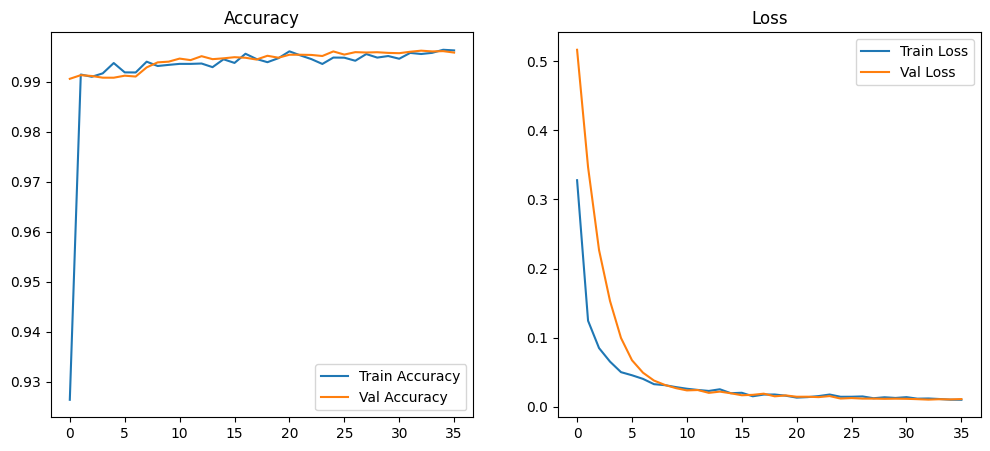

In [ ]:

# STEP 7 — Plot accuracy and loss

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')
plt.show()


In [ ]:
model_seg.save('resnet50_segmentation_model.h5')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [ ]:
def dice_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)

def iou_coef(y_true, y_pred, smooth=1):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection
    return (intersection + smooth) / (union + smooth)


In [ ]:
predicted_masks = []

for i, row in test_df.iterrows():
    img = cv2.imread(row['image_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to match model input
    img_resized = cv2.resize(img_rgb, (128,128))

    # Normalize and expand dimensions
    X = np.expand_dims(img_resized.astype(np.float32)/255.0, axis=0)

    # Predict mask
    pred_mask = model_seg.predict(X)[0].squeeze()

    # Binarize mask
    pred_mask_bin = (pred_mask > 0.5).astype(np.uint8)
    predicted_masks.append(pred_mask_bin)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━

In [ ]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io  # ✅ Import skimage.io for reading images

# --------------------------
# 1️⃣ Create DataFrame with predictions
# --------------------------
df_pred = pd.DataFrame({
    'image_path': test_df['image_path'].values,
    'mask_path': test_df['mask_path'].values,
    'predicted_mask': predicted_masks,
    'has_mask': [1 if np.sum(m) > 0 else 0 for m in predicted_masks]
})

Sample 1: TCGA_HT_7692_19960724/TCGA_HT_7692_19960724_17.tif
 - Predicted mask shape: (256, 256)
 - Predicted mask positive pixels: 836
 - Original mask positive pixels: 772
 - Overlap pixels: 718


Sample 2: TCGA_CS_6665_20010817/TCGA_CS_6665_20010817_9.tif
 - Predicted mask shape: (256, 256)
 - Predicted mask positive pixels: 52
 - Original mask positive pixels: 0
 - Overlap pixels: 0


Sample 3: TCGA_FG_7637_20000922/TCGA_FG_7637_20000922_22.tif
 - Predicted mask shape: (256, 256)
 - Predicted mask positive pixels: 912
 - Original mask positive pixels: 2113
 - Overlap pixels: 910


Sample 4: TCGA_CS_6669_20020102/TCGA_CS_6669_20020102_7.tif
 - Predicted mask shape: (256, 256)
 - Predicted mask positive pixels: 492
 - Original mask positive pixels: 0
 - Overlap pixels: 0


Sample 5: TCGA_HT_8106_19970727/TCGA_HT_8106_19970727_15.tif
 - Predicted mask shape: (256, 256)
 - Predicted mask positive pixels: 3172
 - Original mask positive pixels: 4420
 - Overlap pixels: 3014


Sample 6: TC

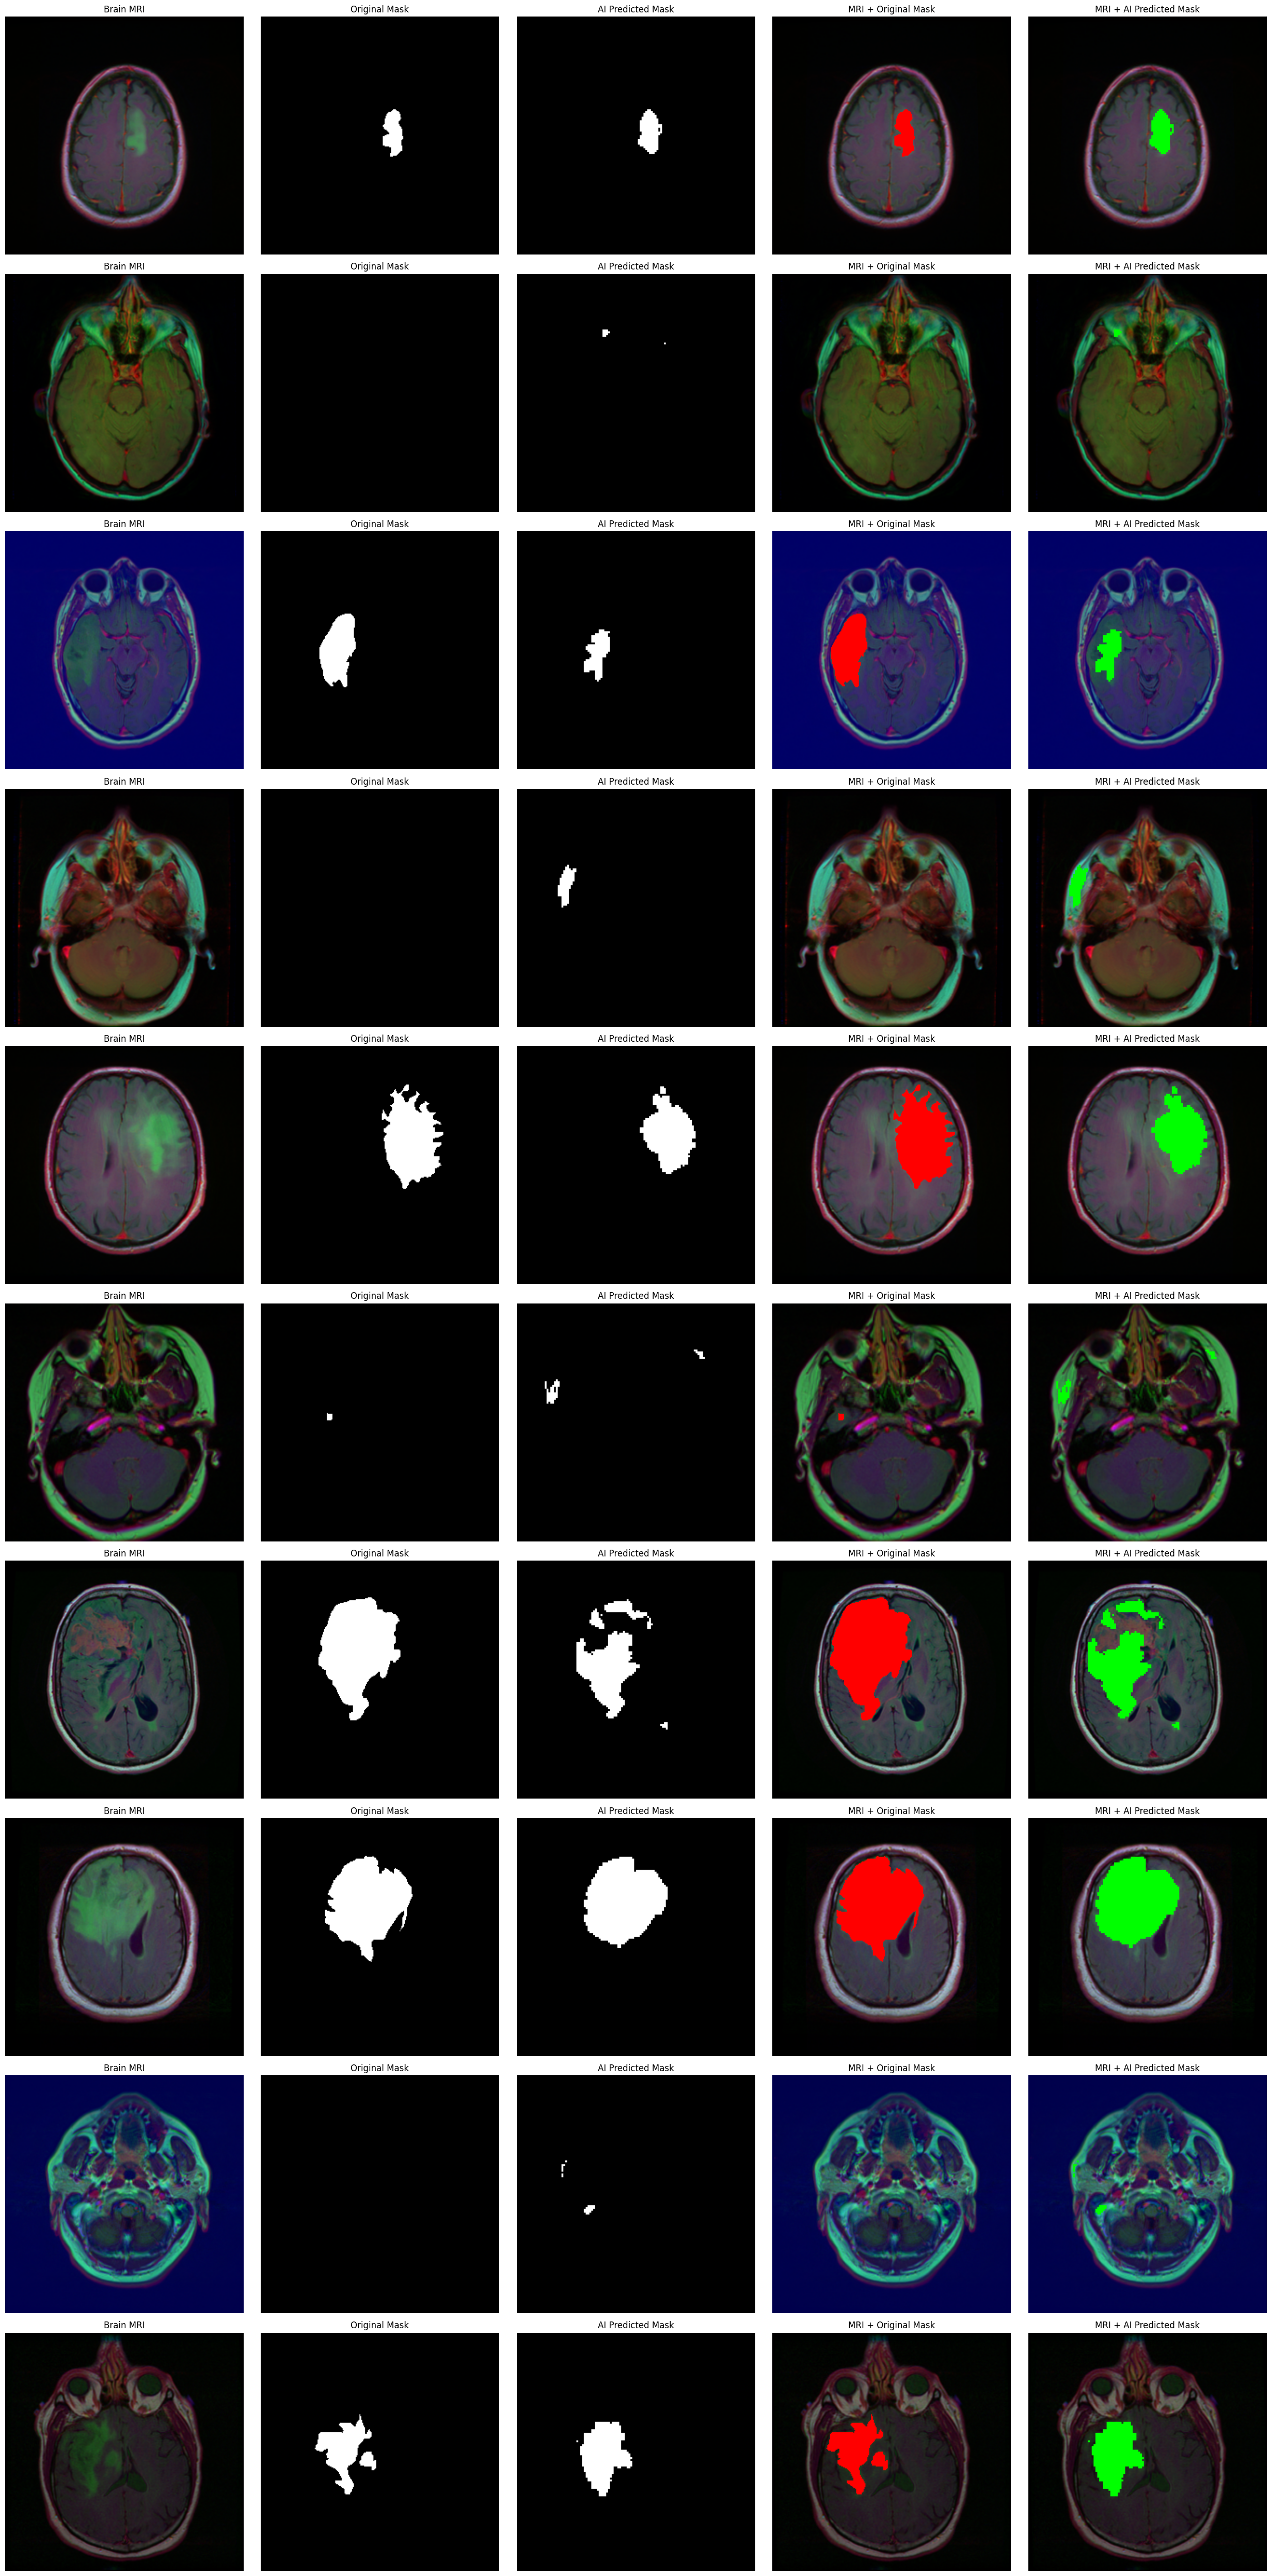

In [ ]:

count = 0
num_samples = 10
fig, axs = plt.subplots(num_samples, 5, figsize=(25, num_samples*5))

for i in range(len(df_pred)):
    if df_pred['has_mask'].iloc[i] == 1 and count < num_samples:
        # Original MRI
        img = io.imread(df_pred.image_path.iloc[i])
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]  # original image size
        axs[count,0].imshow(img_rgb)
        axs[count,0].set_title("Brain MRI")
        axs[count,0].axis('off')

        # Original mask
        mask = io.imread(df_pred.mask_path.iloc[i])
        axs[count,1].imshow(mask, cmap='gray')
        axs[count,1].set_title("Original Mask")
        axs[count,1].axis('off')

        # Predicted mask
        predicted_mask = np.asarray(df_pred.predicted_mask.iloc[i])*255
        predicted_mask_resized = cv2.resize(predicted_mask, (w,h), interpolation=cv2.INTER_NEAREST)
        axs[count,2].imshow(predicted_mask_resized, cmap='gray')
        axs[count,2].set_title("AI Predicted Mask")
        axs[count,2].axis('off')

        # MRI + Original Mask (Red overlay)
        img_orig_mask = img_rgb.copy()
        img_orig_mask[mask>127] = [255,0,0]
        axs[count,3].imshow(img_orig_mask)
        axs[count,3].set_title("MRI + Original Mask")
        axs[count,3].axis('off')

        # MRI + Predicted Mask (Green overlay)
        img_pred_mask = img_rgb.copy()
        img_pred_mask[predicted_mask_resized>127] = [0,255,0]
        axs[count,4].imshow(img_pred_mask)
        axs[count,4].set_title("MRI + AI Predicted Mask")
        axs[count,4].axis('off')

        # Print numeric values
        print(f"Sample {count+1}: {df_pred.image_path.iloc[i]}")
        print(" - Predicted mask shape:", predicted_mask_resized.shape)
        print(" - Predicted mask positive pixels:", np.sum(predicted_mask_resized>127))
        print(" - Original mask positive pixels:", np.sum(mask>127))
        print(" - Overlap pixels:", np.sum((predicted_mask_resized>127) & (mask>127)))
        print("\n")

        count += 1

fig.tight_layout()
plt.show()